In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/predict-the-building-safety-under-the-earthquake/sample_submission.csv
/kaggle/input/predict-the-building-safety-under-the-earthquake/train.csv
/kaggle/input/predict-the-building-safety-under-the-earthquake/test.csv


### Read files

In [2]:
train = pd.read_csv("/kaggle/input/predict-the-building-safety-under-the-earthquake/train.csv")
test = pd.read_csv("/kaggle/input/predict-the-building-safety-under-the-earthquake/test.csv")
submission = pd.read_csv("/kaggle/input/predict-the-building-safety-under-the-earthquake/sample_submission.csv")

In [3]:
train

,Column fy Mpa,Beam fy Mpa,Columns 1-3 I mm4*10^6,Columns 4-6 I mm4*10^6,Columns 1-3 A mm2,Columns 4-6 A mm2,Beam I mm4*10^6,Spans,Number of floors,Floor height m,...,Facade Load kN/m,PGA g,Magnitude,Distance to fault km,Period s,Max drift mm,Final Dead Load,Final Live Load,soil_class__B,soil_class__C
0,275.0,235.0,16.730,10.330,3877.0,3142.0,1119.00,5.0,4.0,4.0,...,3.0,0.171,6.00,17.28,5.178486,35.052122,10.5,7.0,0.0,1.0
1,235.0,235.0,229.300,182.600,12437.0,11253.0,117.70,3.0,6.0,4.0,...,4.0,0.150,6.33,18.96,4.539964,89.310331,12.0,8.0,0.0,1.0
2,275.0,235.0,276.900,0.000,13347.0,0.0,117.70,6.0,3.0,4.0,...,1.0,0.171,6.00,17.28,1.412026,31.485753,15.0,10.0,0.0,1.0
3,235.0,235.0,10.330,6.062,3142.0,2534.0,920.80,6.0,6.0,3.0,...,1.0,0.283,7.28,19.74,2.490511,27.250323,4.0,10.0,0.0,1.0
4,355.0,355.0,330.900,0.000,14276.0,0.0,920.80,3.0,2.0,4.0,...,4.0,0.171,6.00,17.28,0.313426,5.109617,8.0,4.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2917,275.0,275.0,6.062,3.492,2534.0,2124.0,19.43,3.0,4.0,3.0,...,4.0,0.283,7.28,19.74,2.423874,39.012098,2.0,4.0,0.0,1.0
2918,275.0,275.0,182.600,0.000,11253.0,0.0,671.20,4.0,3.0,4.0,...,3.0,0.300,6.60,10.27,1.658722,36.361108,24.0,20.0,1.0,0.0
2919,235.0,235.0,1119.000,0.000,21176.0,0.0,337.40,4.0,1.0,4.0,...,3.0,0.300,6.60,10.27,0.278154,15.864853,6.0,4.5,1.0,0.0
2920,355.0,275.0,1119.000,0.000,21176.0,0.0,13.17,3.0,2.0,3.0,...,4.0,0.200,6.77,23.99,0.399766,10.925555,3.5,14.0,0.0,1.0


In [4]:
train.describe()

,Column fy Mpa,Beam fy Mpa,Columns 1-3 I mm4*10^6,Columns 4-6 I mm4*10^6,Columns 1-3 A mm2,Columns 4-6 A mm2,Beam I mm4*10^6,Spans,Number of floors,Floor height m,...,Facade Load kN/m,PGA g,Magnitude,Distance to fault km,Period s,Max drift mm,Final Dead Load,Final Live Load,soil_class__B,soil_class__C
count,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,...,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000
mean,287.539357,262.008898,849.835175,467.743080,14682.852498,7316.087269,349.925204,3.483915,3.503765,3.490760,...,2.017796,0.188300,6.414538,20.627885,1.416228,21.920161,9.654346,8.366530,0.454141,0.545859
std,49.531036,37.801884,1341.443158,1104.060283,8967.826291,9866.534651,436.671341,1.720822,1.731997,0.408004,...,1.418211,0.082292,0.385426,7.743924,1.283466,22.225221,5.884076,4.842449,0.497978,0.497978
min,235.000000,235.000000,3.492000,0.000000,2124.000000,0.000000,1.710000,1.000000,1.000000,3.000000,...,0.000000,0.100000,5.900000,10.270000,0.056110,0.132411,1.500000,1.500000,0.000000,0.000000
25%,235.000000,235.000000,54.100000,0.000000,6434.000000,0.000000,38.920000,2.000000,2.000000,3.000000,...,1.000000,0.123000,6.100000,13.910000,0.478853,7.339454,4.500000,4.000000,0.000000,0.000000
50%,275.000000,235.000000,276.900000,3.492000,13347.000000,2124.000000,117.700000,3.000000,4.000000,3.500000,...,2.000000,0.150000,6.330000,18.960000,0.997742,15.378362,8.000000,7.500000,0.000000,1.000000
75%,355.000000,275.000000,1119.000000,276.900000,21176.000000,13347.000000,623.900000,5.000000,5.000000,4.000000,...,3.000000,0.283000,6.690000,25.500000,1.935972,29.595909,14.000000,12.000000,1.000000,1.000000
max,355.000000,355.000000,6447.000000,5538.000000,40005.000000,34685.000000,1752.000000,6.000000,6.000000,4.000000,...,4.000000,0.354000,7.280000,35.660000,8.684904,275.706598,24.000000,20.000000,1.000000,1.000000


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Column fy Mpa           2922 non-null   float64
 1   Beam fy Mpa             2922 non-null   float64
 2   Columns 1-3 I mm4*10^6  2922 non-null   float64
 3   Columns 4-6 I mm4*10^6  2922 non-null   float64
 4   Columns 1-3 A mm2       2922 non-null   float64
 5   Columns 4-6 A mm2       2922 non-null   float64
 6   Beam I mm4*10^6         2922 non-null   float64
 7   Spans                   2922 non-null   float64
 8   Number of floors        2922 non-null   float64
 9   Floor height m          2922 non-null   float64
 10  Span width m            2922 non-null   float64
 11  LLRS tributary width m  2922 non-null   float64
 12  Floor mass kg           2922 non-null   float64
 13  Facade Load kN/m        2922 non-null   float64
 14  PGA g                   2922 non-null   

In [6]:
train.isna().sum()

Column fy Mpa             0
Beam fy Mpa               0
Columns 1-3 I mm4*10^6    0
Columns 4-6 I mm4*10^6    0
Columns 1-3 A mm2         0
Columns 4-6 A mm2         0
Beam I mm4*10^6           0
Spans                     0
Number of floors          0
Floor height m            0
Span width m              0
LLRS tributary width m    0
Floor mass kg             0
Facade Load kN/m          0
PGA g                     0
Magnitude                 0
Distance to fault km      0
Period s                  0
Max drift mm              0
Final Dead Load           0
Final Live Load           0
soil_class__B             0
soil_class__C             0
dtype: int64

In [7]:
test

,Column fy Mpa,Beam fy Mpa,Columns 1-3 I mm4*10^6,Columns 4-6 I mm4*10^6,Columns 1-3 A mm2,Columns 4-6 A mm2,Beam I mm4*10^6,Spans,Number of floors,Floor height m,...,Floor mass kg,Facade Load kN/m,PGA g,Magnitude,Distance to fault km,Period s,Final Dead Load,Final Live Load,soil_class__B,soil_class__C
0,355.0,355.0,5538.00,4221.000,34685.0,32053.0,231.30,4.0,4.0,3.0,...,17579.6280,4.0,0.354,6.50,15.82,0.216653,7.5,5.0,1.0,0.0
1,355.0,235.0,1119.00,0.000,21176.0,0.0,482.00,5.0,1.0,4.0,...,15968.5020,0.0,0.140,5.90,25.50,0.076358,9.0,6.0,0.0,1.0
2,235.0,235.0,10.33,6.062,3142.0,2534.0,1752.00,1.0,6.0,3.0,...,10531.4616,2.0,0.283,7.28,19.74,2.384245,8.0,12.0,0.0,1.0
3,355.0,235.0,637.20,0.000,17803.0,0.0,231.30,2.0,1.0,3.0,...,165958.2144,4.0,0.300,6.60,10.27,0.337537,21.0,7.0,1.0,0.0
4,275.0,235.0,1119.00,0.000,21176.0,0.0,13.17,1.0,2.0,3.0,...,4496.8770,0.0,0.150,6.20,13.91,0.180089,1.5,6.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320,275.0,235.0,104.50,77.630,8682.0,7684.0,13.17,5.0,5.0,4.0,...,28347.6600,4.0,0.150,6.33,18.96,2.142105,7.5,7.5,0.0,1.0
321,355.0,275.0,10.33,6.062,3142.0,2534.0,337.40,1.0,5.0,3.0,...,24962.2560,2.0,0.140,5.90,25.50,2.938106,4.0,16.0,0.0,1.0
322,355.0,235.0,1119.00,0.000,21176.0,0.0,162.70,1.0,3.0,4.0,...,23983.3440,0.0,0.150,6.20,13.91,0.778842,15.0,7.5,1.0,0.0
323,275.0,275.0,637.20,0.000,17803.0,0.0,162.70,2.0,1.0,3.0,...,32654.8728,4.0,0.150,6.20,13.91,0.156314,15.0,9.0,1.0,0.0


In [8]:
test.isna().sum()

Column fy Mpa             0
Beam fy Mpa               0
Columns 1-3 I mm4*10^6    0
Columns 4-6 I mm4*10^6    0
Columns 1-3 A mm2         0
Columns 4-6 A mm2         0
Beam I mm4*10^6           0
Spans                     0
Number of floors          0
Floor height m            0
Span width m              0
LLRS tributary width m    0
Floor mass kg             0
Facade Load kN/m          0
PGA g                     0
Magnitude                 0
Distance to fault km      0
Period s                  0
Final Dead Load           0
Final Live Load           0
soil_class__B             0
soil_class__C             0
dtype: int64

In [9]:
submission

,Index,Max drift mm
0,0,18.60
1,1,-1.92
2,2,41.58
3,3,25.69
4,4,-5.01
...,...,...
320,320,24.14
321,321,30.55
322,322,3.18
323,323,3.84


### Analyze train

In [10]:
train['Max drift mm'] = round(train['Max drift mm'],2)

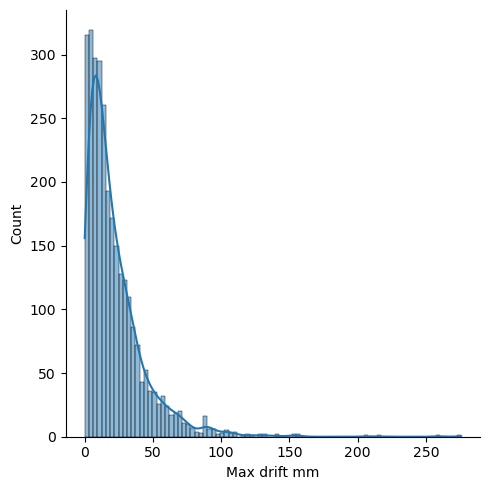

In [11]:
sns.displot(train['Max drift mm'], kde=True)

In [12]:
train["Max drift mm"].value_counts()

13.48    5
9.23     5
0.65     5
1.80     5
15.37    5
        ..
23.55    1
7.28     1
16.54    1
5.36     1
10.93    1
Name: Max drift mm, Length: 2169, dtype: int64

In [13]:
is_multi = train["Max drift mm"].value_counts() > 1
filtered = train[train["Max drift mm"].isin(is_multi[is_multi].index)]
train = filtered
train

,Column fy Mpa,Beam fy Mpa,Columns 1-3 I mm4*10^6,Columns 4-6 I mm4*10^6,Columns 1-3 A mm2,Columns 4-6 A mm2,Beam I mm4*10^6,Spans,Number of floors,Floor height m,...,Facade Load kN/m,PGA g,Magnitude,Distance to fault km,Period s,Max drift mm,Final Dead Load,Final Live Load,soil_class__B,soil_class__C
8,275.0,235.0,869.700,0.0,19754.0,0.0,920.800,5.0,3.0,3.5,...,3.0,0.283,7.28,19.74,0.232733,6.24,2.0,2.0,0.0,1.0
9,235.0,235.0,3034.000,2153.0,28583.0,26048.0,1119.000,1.0,6.0,3.5,...,4.0,0.100,6.10,32.84,0.854743,9.87,16.0,16.0,1.0,0.0
13,355.0,235.0,3.492,0.0,2124.0,0.0,920.800,6.0,2.0,4.0,...,4.0,0.140,5.90,25.50,4.789651,12.07,12.0,8.0,0.0,1.0
19,235.0,235.0,6447.000,5538.0,40005.0,34685.0,482.000,3.0,6.0,3.5,...,4.0,0.123,6.19,12.90,1.803414,9.22,24.0,16.0,0.0,1.0
20,235.0,235.0,1119.000,0.0,21176.0,0.0,19.430,1.0,2.0,3.0,...,3.0,0.150,6.20,13.91,0.355339,8.07,6.0,3.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,355.0,235.0,1752.000,1412.0,24164.0,22646.0,5.412,1.0,5.0,3.5,...,0.0,0.150,6.33,18.96,1.024828,19.94,2.0,6.0,0.0,1.0
2916,355.0,355.0,869.700,637.2,19754.0,17803.0,162.700,5.0,6.0,4.0,...,4.0,0.100,6.69,35.66,2.095025,11.66,8.0,6.0,1.0,0.0
2918,275.0,275.0,182.600,0.0,11253.0,0.0,671.200,4.0,3.0,4.0,...,3.0,0.300,6.60,10.27,1.658722,36.36,24.0,20.0,1.0,0.0
2919,235.0,235.0,1119.000,0.0,21176.0,0.0,337.400,4.0,1.0,4.0,...,3.0,0.300,6.60,10.27,0.278154,15.86,6.0,4.5,1.0,0.0


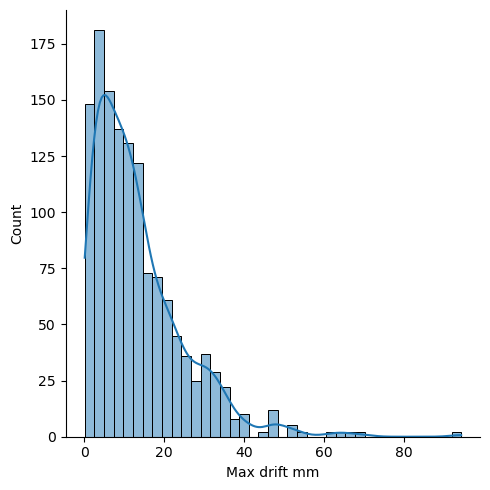

In [14]:
sns.displot(train['Max drift mm'], kde=True)

<AxesSubplot:xlabel='Number of floors', ylabel='Max drift mm'>

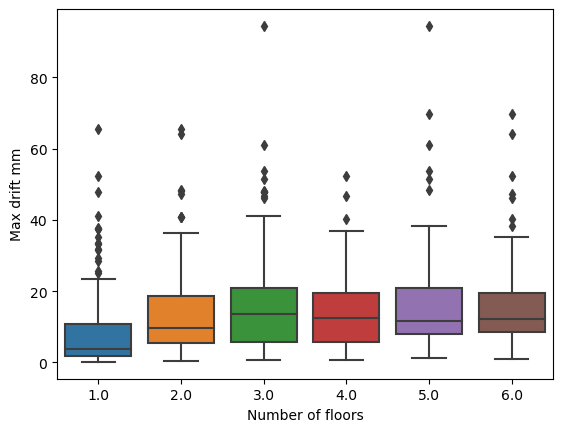

In [15]:
sns.boxplot(data=train, x="Number of floors", y="Max drift mm")

<AxesSubplot:xlabel='Floor height m', ylabel='Max drift mm'>

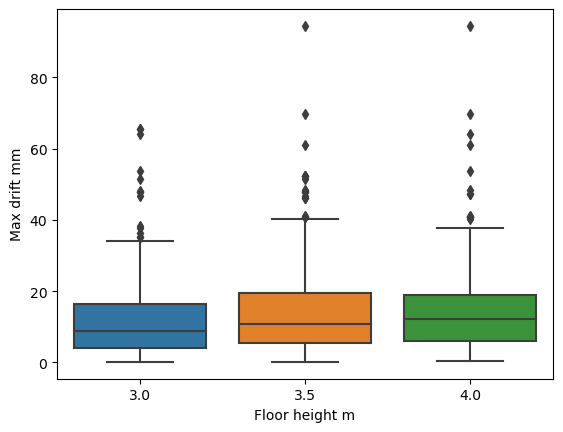

In [16]:
sns.boxplot(data=train, x="Floor height m", y="Max drift mm")

<AxesSubplot:xlabel='Distance to fault km', ylabel='Max drift mm'>

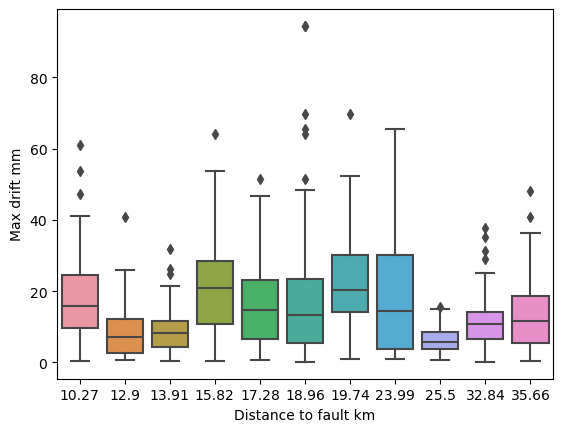

In [17]:
sns.boxplot(data=train, x="Distance to fault km", y="Max drift mm")

<AxesSubplot:>

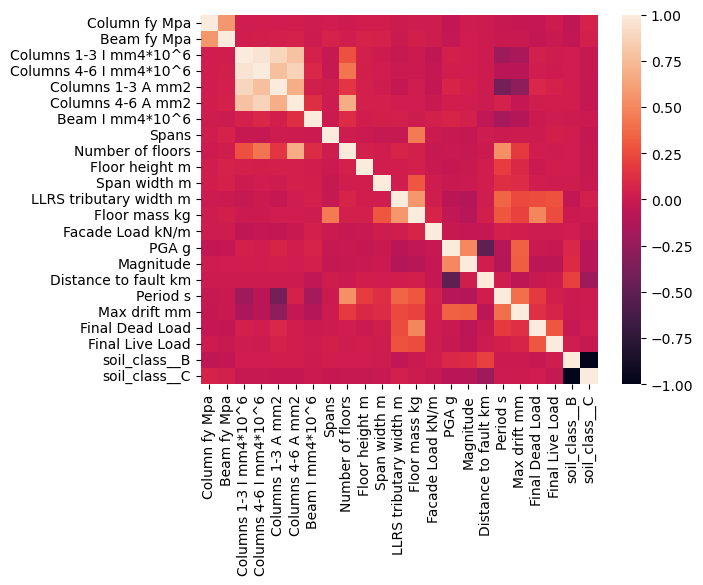

In [18]:
corr = train.corr()
sns.heatmap(corr)

In [19]:
corr

,Column fy Mpa,Beam fy Mpa,Columns 1-3 I mm4*10^6,Columns 4-6 I mm4*10^6,Columns 1-3 A mm2,Columns 4-6 A mm2,Beam I mm4*10^6,Spans,Number of floors,Floor height m,...,Facade Load kN/m,PGA g,Magnitude,Distance to fault km,Period s,Max drift mm,Final Dead Load,Final Live Load,soil_class__B,soil_class__C
Column fy Mpa,1.000000,0.571658,0.021661,0.025671,0.022110,0.030635,0.013311,0.021099,0.001497,0.026901,...,0.013778,-0.040589,0.010573,0.006765,-0.022069,-0.030178,-0.035366,0.006117,-0.057098,0.057098
Beam fy Mpa,0.571658,1.000000,0.031172,0.032174,0.039625,0.051518,0.005110,0.060640,0.028479,0.057864,...,0.013418,-0.038016,0.023013,0.007811,-0.008910,-0.013691,-0.039838,-0.011914,-0.040592,0.040592
Columns 1-3 I mm4*10^6,0.021661,0.031172,1.000000,0.958702,0.884552,0.782775,0.051269,-0.016406,0.272546,0.039063,...,-0.055356,0.039109,0.025152,0.000883,-0.207875,-0.162614,0.041510,0.014837,0.017191,-0.017191
Columns 4-6 I mm4*10^6,0.025671,0.032174,0.958702,1.000000,0.767731,0.873985,0.080997,-0.022422,0.416254,0.032697,...,-0.038703,0.024487,0.019351,0.003474,-0.078206,-0.081993,0.019722,0.000955,0.018746,-0.018746
Columns 1-3 A mm2,0.022110,0.039625,0.884552,0.767731,1.000000,0.681653,0.038319,0.010465,0.149359,0.040858,...,-0.041858,0.064460,0.036494,0.002078,-0.406029,-0.287055,0.081575,0.054410,0.024536,-0.024536
Columns 4-6 A mm2,0.030635,0.051518,0.782775,0.873985,0.681653,1.000000,0.120884,0.003341,0.672103,0.039579,...,-0.015414,0.023486,0.017499,0.003143,0.049410,-0.035688,0.029919,0.029729,0.026524,-0.026524
Beam I mm4*10^6,0.013311,0.005110,0.051269,0.080997,0.038319,0.120884,1.000000,-0.006005,0.108179,0.030907,...,0.039856,0.064962,0.044611,-0.047244,-0.172509,-0.105190,-0.004983,0.012838,0.001032,-0.001032
Spans,0.021099,0.060640,-0.016406,-0.022422,0.010465,0.003341,-0.006005,1.000000,0.010211,-0.004162,...,-0.006386,-0.015710,-0.027808,0.013621,-0.007695,0.004215,0.005884,0.037635,0.028390,-0.028390
Number of floors,0.001497,0.028479,0.272546,0.416254,0.149359,0.672103,0.108179,0.010211,1.000000,0.045663,...,-0.020790,-0.012244,-0.016947,-0.000114,0.533032,0.175849,0.019795,0.011086,0.017669,-0.017669
Floor height m,0.026901,0.057864,0.039063,0.032697,0.040858,0.039579,0.030907,-0.004162,0.045663,1.000000,...,-0.010570,-0.030336,-0.009547,0.028938,0.184804,0.089183,-0.000026,0.026998,0.020725,-0.020725


### Define X, y and X_test

In [20]:
y = train.pop('Max drift mm')
X = train
X_test = test
X.shape, X_test.shape, len(y)

((1321, 22), (325, 22), 1321)

### Split dataset into training and validation sets

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.1, random_state=42)
X_train.shape, X_val.shape, y_train.shape, y_val.shape, X_test.shape

((1188, 22), (133, 22), (1188,), (133,), (325, 22))

### Tensorflow

In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.callbacks import ModelCheckpoint, EarlyStopping
print(tf.__version__)

2.11.0


### Rescale 

In [23]:
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(X_train))
print(normalizer.mean.numpy())

[[2.8782834e+02 2.6180130e+02 1.0460157e+03 5.8377814e+02 1.6463867e+04
  8.0820015e+03 3.6178201e+02 3.4755898e+00 3.4461277e+00 3.4718015e+00
  5.4149814e+00 9.1102686e+00 7.7888891e+04 1.9941077e+00 1.7505391e-01
  6.3505049e+00 2.1247852e+01 1.1647344e+00 8.9200335e+00 8.0357733e+00
  4.7558916e-01 5.2441078e-01]]


In [24]:
first = np.array(X_train[:1])

with np.printoptions(precision=2, suppress=True):
  print('First example:', first)
  print()
  print('Normalized:', normalizer(first).numpy())

First example: [[  355.     355.     330.9    276.9  14276.   13347.     920.8      3.
      6.       3.       8.      15.   62038.55     3.       0.28     7.28
     19.74     0.99     2.5      2.5      0.       1.  ]]

Normalized: [[ 1.34  2.43 -0.48 -0.25 -0.24  0.49  1.28 -0.28  1.45 -1.15  1.49  1.04
  -0.19  0.7   1.36  2.52 -0.19 -0.14 -1.13 -1.18 -0.95  0.95]]


### Build model (DNN)

In [25]:
def build_and_compile_model(norm):
  model = keras.Sequential([
      normalizer,
      layers.Dense(160, kernel_initializer='normal',activation='relu'),
      layers.Dense(256, kernel_initializer='normal',activation='relu'),
      layers.Dense(64, kernel_initializer='normal',activation='relu'),
      layers.Dense(1, kernel_initializer='normal',activation='linear')
  ])

  model.compile(loss='mean_absolute_error',
                optimizer=tf.keras.optimizers.Adam(0.001))
  return model

In [26]:
model = build_and_compile_model(normalizer)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization (Normalizatio  (None, 22)               45        
 n)                                                              
                                                                 
 dense (Dense)               (None, 160)               3680      
                                                                 
 dense_1 (Dense)             (None, 256)               41216     
                                                                 
 dense_2 (Dense)             (None, 64)                16448     
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                                 
Total params: 61,454
Trainable params: 61,409
Non-trainable params: 45
___________________________________________________

In [27]:
early_stopping = EarlyStopping(monitor='val_loss', mode='min', patience=25, verbose=1)
mc = ModelCheckpoint ('best_model.h5', monitor='val_loss', mode='min', save_best_only=True)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    verbose=1, epochs=200, callbacks=[early_stopping, mc])

Epoch 1/200
38/38 [==============================] - 2s 12ms/step - loss: 11.0146 - val_loss: 7.5711
Epoch 2/200
38/38 [==============================] - 0s 4ms/step - loss: 6.7025 - val_loss: 5.3660
Epoch 3/200
38/38 [==============================] - 0s 4ms/step - loss: 5.9052 - val_loss: 5.4657
Epoch 4/200
38/38 [==============================] - 0s 5ms/step - loss: 5.6884 - val_loss: 5.1878
Epoch 5/200
38/38 [==============================] - 0s 4ms/step - loss: 5.5337 - val_loss: 5.2259
Epoch 6/200
38/38 [==============================] - 0s 4ms/step - loss: 5.3468 - val_loss: 5.0447
Epoch 7/200
38/38 [==============================] - 0s 5ms/step - loss: 5.1422 - val_loss: 5.0433
Epoch 8/200
38/38 [==============================] - 0s 4ms/step - loss: 4.9657 - val_loss: 5.0937
Epoch 9/200
38/38 [==============================] - 0s 4ms/step - loss: 4.7700 - val_loss: 4.9004
Epoch 10/200
38/38 [==============================] - 0s 4ms/step - loss: 4.7498 - val_loss: 5.1207
Epoch 1

In [28]:
results = model.evaluate(X_val, y_val, batch_size=128)

2/2 [==============================] - 0s 5ms/step - loss: 3.8337


### Predictions

In [29]:
predictions = model.predict(X_test)
predictions = np.round_(predictions, decimals = 2)
predictions = predictions.flatten()
predictions

11/11 [==============================] - 0s 2ms/step


array([ 9.31,  0.93, 35.98, 25.53,  3.68, 38.26, 60.34, 16.05, 19.92,
       35.09,  1.03,  4.37, 25.42,  2.85,  7.83, 32.42, 33.32, 28.17,
       25.28, 33.78,  6.43, 40.71,  9.52, 36.17, 34.29,  4.87, 31.67,
       37.09, 27.25,  5.95, 46.8 ,  2.28, 11.7 , 28.43, 36.57,  8.85,
       15.89, 27.58, 24.36, 19.9 , 14.94, 26.2 , 12.75, 43.11, 26.38,
       16.71, 20.04, 30.43, 15.28, 22.74, 13.84, 13.  , 29.98, 21.16,
       16.85,  0.2 , 16.34,  7.55, 20.62, 19.68,  9.3 , 46.27, 22.28,
       28.55, 35.91, 13.99, 10.39,  6.31,  9.6 ,  3.  ,  7.1 , 30.1 ,
       54.43, 33.87, 15.46,  9.38, 32.51, 43.55,  4.13, 10.11,  5.53,
       12.28, 18.53, 35.19,  9.47, 13.72,  8.77, 39.53, 49.17, 28.39,
       27.1 , 17.95, 41.06, 14.01, 10.87,  3.9 ,  7.1 , 21.22, 22.97,
       19.23, 12.9 , 52.25, 46.97,  3.82,  3.62, 36.08, 30.25, 16.16,
       16.4 , 14.74,  4.97, 21.2 ,  3.93,  4.29, 13.02, 45.67,  3.35,
       34.93,  3.82,  1.48, 10.03,  1.4 ,  2.79, 51.12, 17.98, 29.64,
       23.46, 15.06,

### Submission

In [30]:
submission['Max drift mm'] = predictions
submission.to_csv('submission.csv', index=False)
submission = pd.read_csv('submission.csv')
submission

,Index,Max drift mm
0,0,9.31
1,1,0.93
2,2,35.98
3,3,25.53
4,4,3.68
...,...,...
320,320,22.06
321,321,13.91
322,322,9.15
323,323,1.67
